In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tkinter import Tk, filedialog
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


In [2]:
dataset_path = r"C:\Users\ONKAR SHAHAGADKAR\Desktop\DL\IndianActor\Indian_actors_faces"


In [3]:
def load_images_from_folder(folder_path):
    images = []
    labels = []
    label_map = {}
    label_count = 0

    for actor_name in os.listdir(folder_path):
        actor_folder = os.path.join(folder_path, actor_name)
        if os.path.isdir(actor_folder):
            print(f"[INFO] Processing: {actor_name}")
            for image_name in os.listdir(actor_folder):
                image_path = os.path.join(actor_folder, image_name)
                img = cv2.imread(image_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (224, 224))
                    images.append(img)
                    if actor_name not in label_map:
                        label_map[actor_name] = label_count
                        label_count += 1
                    labels.append(label_map[actor_name])
                else:
                    print(f"[WARNING] Couldn't load image: {image_path}")
    print(f"[INFO] Total Images Loaded: {len(images)}")
    return np.array(images), np.array(labels), label_map

images, labels, label_map = load_images_from_folder(dataset_path)


[INFO] Processing: abhay_deol
[INFO] Processing: adil_hussain
[INFO] Processing: ajay_devgn
[INFO] Processing: akshaye_khanna
[INFO] Processing: akshay_kumar
[INFO] Processing: amitabh_bachchan
[INFO] Processing: amjad_khan
[INFO] Processing: amole_gupte
[INFO] Processing: amol_palekar
[INFO] Processing: amrish_puri
[INFO] Processing: anil_kapoor
[INFO] Processing: annu_kapoor
[INFO] Processing: anupam_kher
[INFO] Processing: anushka_shetty
[INFO] Processing: arshad_warsi
[INFO] Processing: aruna_irani
[INFO] Processing: ashish_vidyarthi
[INFO] Processing: asrani
[INFO] Processing: atul_kulkarni
[INFO] Processing: ayushmann_khurrana
[INFO] Processing: boman_irani
[INFO] Processing: chiranjeevi
[INFO] Processing: chunky_panday
[INFO] Processing: danny_denzongpa
[INFO] Processing: darsheel_safary
[INFO] Processing: deepika_padukone
[INFO] Processing: deepti_naval
[INFO] Processing: dev_anand
[INFO] Processing: dharmendra
[INFO] Processing: dilip_kumar
[INFO] Processing: dimple_kapadia
[I

In [6]:
#Train-Test Split + Preprocessing
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))


In [ ]:
#Build and Train the CNN
from tensorflow.keras.models import Sequential, load_model
import os

model_path = "actor_face_recognition_model.h5"

# Check if model already trained and saved
if os.path.exists(model_path):
    print("[INFO] Loading existing model from disk...")
    model = load_model(model_path)

else:
    print("[INFO] No saved model found. Training a new model...")

    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(len(label_map), activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train with high epochs for better accuracy
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

    # Save model after training
    model.save(model_path)
    print("[INFO] Model saved to disk.")


[INFO] No saved model found. Training a new model...


C:\Users\ONKAR SHAHAGADKAR\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 96s 628ms/step - accuracy: 0.0114 - loss: 5.1159 - val_accuracy: 0.0469 - val_loss: 4.7245
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 559ms/step - accuracy: 0.0837 - loss: 4.3398 - val_accuracy: 0.1632 - val_loss: 3.8509
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 95s 631ms/step - accuracy: 0.3953 - loss: 2.6262 - val_accuracy: 0.2561 - val_loss: 3.5617
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2555s 17s/step - accuracy: 0.7528 - loss: 1.0268 - val_accuracy: 0.2736 - val_loss: 4.1131
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 456ms/step - accuracy: 0.9272 - loss: 0.3209 - val_accuracy: 0.2979 - val_loss: 4.9006
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 470ms/step - accuracy: 0.9770 - loss: 0.1148 - val_accuracy: 0.3130 - val_loss: 5.3255
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 483ms/step - accuracy: 0.9878 - loss: 0.0511 - val_accuracy: 0.3130 - val_loss: 5.7795
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 517ms/step - accuracy: 0.9977 - loss: 0

[INFO] Model saved to disk.


In [7]:
#Loading the Trained Model for Prediction
from tensorflow.keras.models import load_model

model_path = "actor_face_recognition_model.h5"
model = load_model(model_path)

print("[INFO] Model loaded. Ready to predict!")

[INFO] Model loaded. Ready to predict!


In [8]:
#Evaluating the Model on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"[INFO] Test Accuracy: {test_acc:.2f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.3215 - loss: 7.0237
[INFO] Test Accuracy: 0.32


In [9]:
#Actor Prediction from User-Selected Image
from tkinter import filedialog
from PIL import Image
import tkinter as tk

def predict_actor_from_image():
    # File dialog to select image
    file_path = filedialog.askopenfilename()
    if not file_path:
        print("[ERROR] No image selected.")
        return

    # Load and preprocess image
    img = Image.open(file_path).resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_actor = list(label_map.keys())[list(label_map.values()).index(predicted_index)]

    # Show image with prediction
    plt.imshow(img)
    plt.title(f"Predicted Actor: {predicted_actor}")
    plt.axis('off')
    plt.show()

    print(f"[RESULT] Predicted Actor: {predicted_actor}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


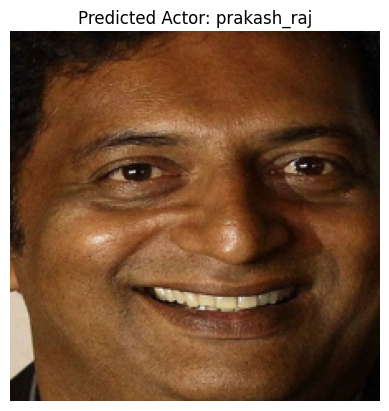

[RESULT] Predicted Actor: prakash_raj


In [14]:
predict_actor_from_image()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


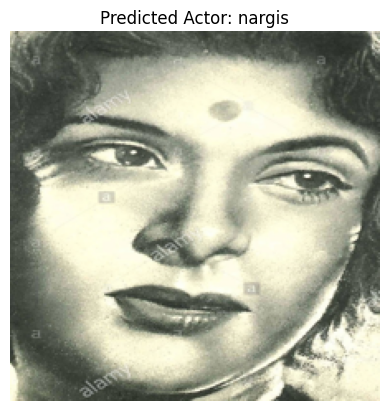

[RESULT] Predicted Actor: nargis


In [16]:
predict_actor_from_image()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


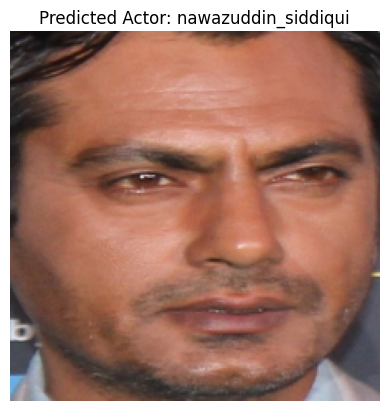

[RESULT] Predicted Actor: nawazuddin_siddiqui


In [17]:
predict_actor_from_image()